In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Furkan-Elif-dataset.pkl to Furkan-Elif-dataset.pkl


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_pickle("Furkan-Elif-dataset.pkl")
print(f"Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
df.head()

Veri seti boyutu: 150 satır, 7 sütun


,building_name,architect,location,year,building_type,coordinates,wiki_url
0,Wikipedia:FAQ/Categorization,Nicholas Grimshaw,None,NaN,Other / Unknown,None,https://en.wikipedia.org/wiki/Wikipedia:FAQ/Ca...
1,125 Park Road,Nicholas Grimshaw,None,NaN,Religious Building,51.52832; -0.16621,https://en.wikipedia.org/wiki/125_Park_Road
2,Amsterdam Bijlmer ArenA station,Nicholas Grimshaw,Amsterdam Netherlands,1971.0,Transport Hub,52.31306; 4.94611,https://en.wikipedia.org/wiki/Amsterdam_Bijlme...
3,Compass Centre,Nicholas Grimshaw,None,NaN,Transport Hub,51.4809; -0.4689,https://en.wikipedia.org/wiki/Compass_Centre
4,Donald Danforth Plant Science Center,Nicholas Grimshaw,975 North Warson Road,1998.0,Other / Unknown,38.67411; -90.39671,https://en.wikipedia.org/wiki/Donald_Danforth_...


In [ ]:
# 1a) Her sütundaki veri tiplerinin tutarlılığı
print("=== Sütunlardaki Veri Tipleri ===")
for col in df.columns:
    types = df[col].apply(lambda x: type(x).__name__).unique()
    print(f"{col}: {types}")

=== Sütunlardaki Veri Tipleri ===
building_name: ['str']
architect: ['str']
location: ['NoneType' 'str']
year: ['float']
building_type: ['str']
coordinates: ['NoneType' 'str']
wiki_url: ['str']


In [ ]:
# 1b) Kategorik değişkenlerin eşsiz değerleri
cat_cols = df.select_dtypes(include=object).columns
for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique):")
    print(df[col].unique())


building_name (143 unique):
['Wikipedia:FAQ/Categorization' '125 Park Road'
 'Amsterdam Bijlmer ArenA station' 'Compass Centre'
 'Donald Danforth Plant Science Center' 'East India Dock House'
 'Eden Project' 'Elizabeth line' 'Enneüs Heerma Bridge'
 'Experimental Media and Performing Arts Center' 'Fulton Center'
 'Goodwood plant' 'London Bridge station'
 'National Space Centre (England)' 'Neville Bonner Bridge'
 'Oxford Ice Rink' 'Phillip and Patricia Frost Museum of Science'
 'Pulkovo Airport' 'RAC Regional Control Centre' "Sainsbury's, Camden"
 'The Ship, Derriford' 'St Botolph Building' 'Thermae Bath Spa'
 'Waterloo International railway station' 'Zurich Airport'
 'List of works by Zaha Hadid' '520 West 28th Street'
 'Ark Evelyn Grace Academy' 'Bergisel Ski Jump' 'Biopolis'
 'BMW Central Building' 'Bridge Pavilion' 'Capital Hill Residence'
 'Cardiff Bay Opera House' 'Central Bank of Iraq Tower'
 'Changsha Meixihu International Culture and Arts Centre'
 'CityLife (Milan)' 'CMA CGM To

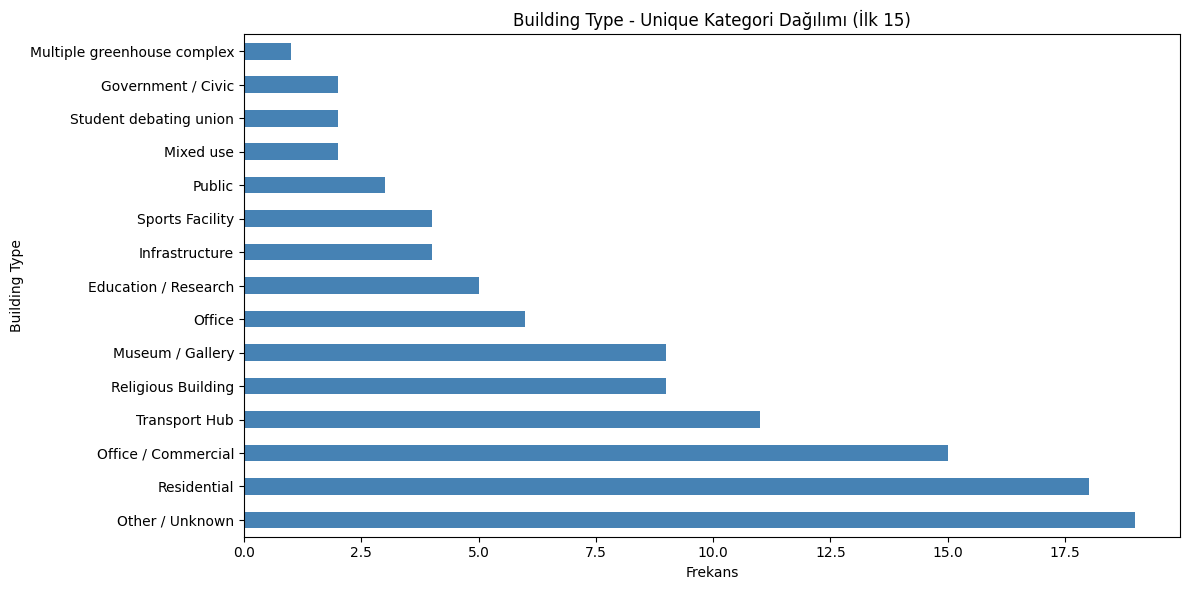

In [ ]:
# 1c) Kategorik değişken sayılarını görselleştirme
# building_type en önemli kategorik sütun olduğu için onu görselleştiriyoruz
plt.figure(figsize=(12, 6))
df['building_type'].value_counts().head(15).plot(kind='barh', color='steelblue')
plt.title('Building Type - Unique Kategori Dağılımı (İlk 15)')
plt.xlabel('Frekans')
plt.ylabel('Building Type')
plt.tight_layout()
plt.show()

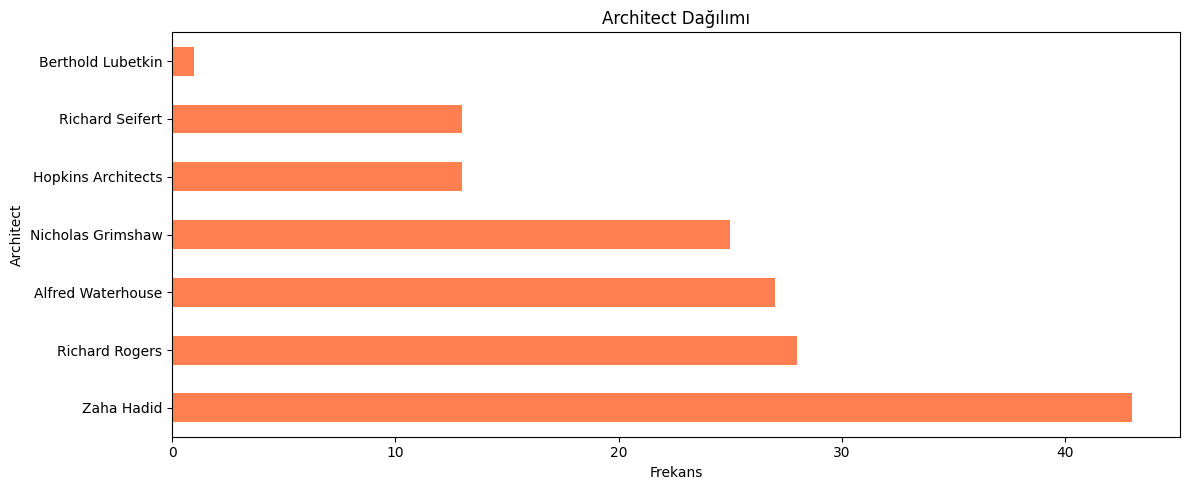

In [ ]:
# architect sütunu için de görselleştirme
plt.figure(figsize=(12, 5))
df['architect'].value_counts().plot(kind='barh', color='coral')
plt.title('Architect Dağılımı')
plt.xlabel('Frekans')
plt.ylabel('Architect')
plt.tight_layout()
plt.show()

In [ ]:
# 2a) Eksik veri oranı tablosu
missing_counts = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Eksik Sayısı': missing_counts,
    'Eksik Yüzdesi (%)': missing_percent.round(2)
})
print(missing_df)

               Eksik Sayısı  Eksik Yüzdesi (%)
building_name             0               0.00
architect                 0               0.00
location                 43              28.67
year                     74              49.33
building_type             0               0.00
coordinates              14               9.33
wiki_url                  0               0.00


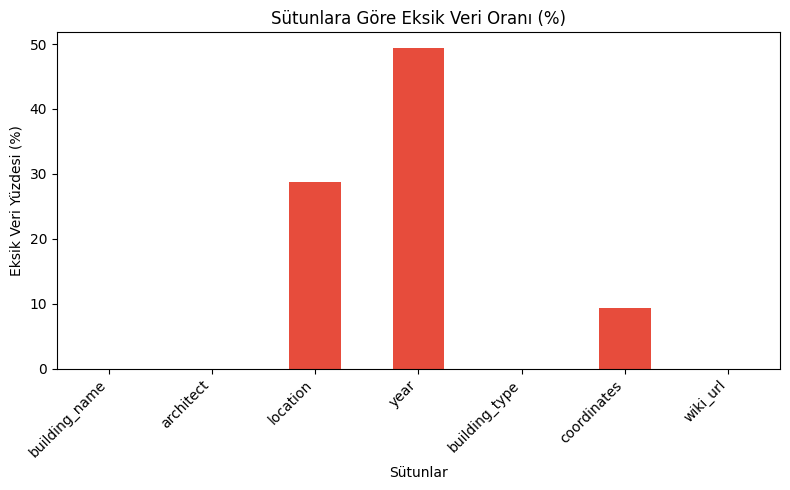

In [ ]:
# 2b) Eksik veri oranını bar chart ile görselleştirme
plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in missing_percent]
missing_percent.plot(kind='bar', color=colors)
plt.title('Sütunlara Göre Eksik Veri Oranı (%)')
plt.ylabel('Eksik Veri Yüzdesi (%)')
plt.xlabel('Sütunlar')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

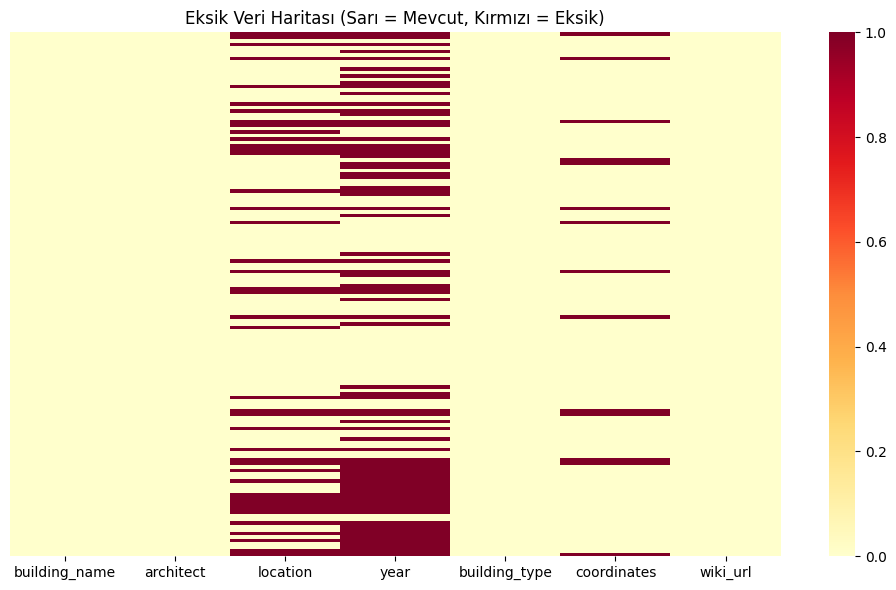

In [ ]:
# 2c) Eksik veri pattern'ini heatmap ile görselleştirme
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=True, yticklabels=False, cmap='YlOrRd')
plt.title('Eksik Veri Haritası (Sarı = Mevcut, Kırmızı = Eksik)')
plt.tight_layout()
plt.show()

In [ ]:
# 2d) Eksik veri tipi analizi (MCAR, MAR, MNAR)
print("=== Eksik Veri Tipi Yorumu ===")
print("""
- location (43 eksik, %28.67): Bazı Wikipedia sayfalarında konum bilgisi bulunmamaktadır.
  Bu eksiklik sayfanın yapısına bağlı olduğundan MAR (Missing At Random) olarak değerlendirilebilir.

- year (74 eksik, %49.33): Yapım yılı bilgisi birçok binada eksiktir.
  Özellikle eski veya az bilinen yapılarda bu bilgi bulunmadığından MNAR (Missing Not At Random)
  olarak değerlendirilebilir.

- coordinates (14 eksik, %9.33): Koordinat bilgisi bazı sayfalarda eksiktir.
  Wikipedia sayfasının formatına bağlı olduğundan MAR olarak değerlendirilebilir.
""")

=== Eksik Veri Tipi Yorumu ===

- location (43 eksik, %28.67): Bazı Wikipedia sayfalarında konum bilgisi bulunmamaktadır.
  Bu eksiklik sayfanın yapısına bağlı olduğundan MAR (Missing At Random) olarak değerlendirilebilir.

- year (74 eksik, %49.33): Yapım yılı bilgisi birçok binada eksiktir.
  Özellikle eski veya az bilinen yapılarda bu bilgi bulunmadığından MNAR (Missing Not At Random)
  olarak değerlendirilebilir.

- coordinates (14 eksik, %9.33): Koordinat bilgisi bazı sayfalarda eksiktir.
  Wikipedia sayfasının formatına bağlı olduğundan MAR olarak değerlendirilebilir.



In [ ]:
# 3a) IQR yöntemi ile outlier tespiti
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    print(f"\n{col} IQR Sınırları: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"{col} outlier sayısı: {len(outliers)}")
    print(f"{col} outlier değerleri: {outliers.values}")


year IQR Sınırları: [1935.00, 2059.00]
year outlier sayısı: 4
year outlier değerleri: [1930. 1918. 1928. 1931.]


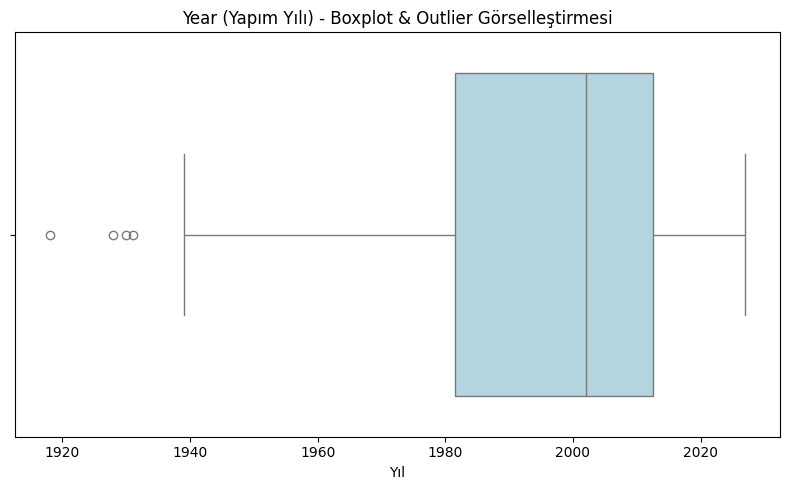

In [ ]:
# 3b) Boxplot ile outlier görselleştirme
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['year'].dropna(), color='lightblue')
plt.title('Year (Yapım Yılı) - Boxplot & Outlier Görselleştirmesi')
plt.xlabel('Yıl')
plt.tight_layout()
plt.show()

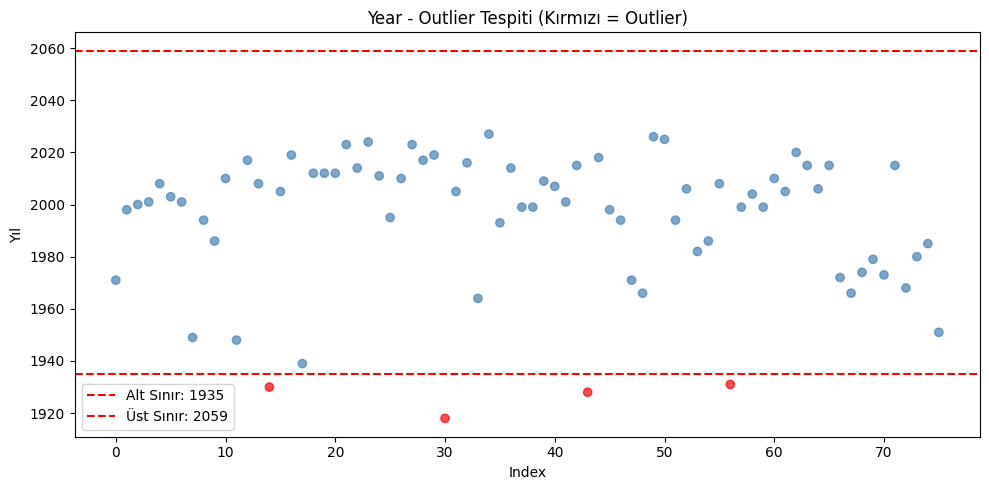

In [ ]:
# 3c) Outlier'ları scatter plot üzerinde işaretleme
col = 'year'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plt.figure(figsize=(10, 5))
colors = ['red' if (x < lower_bound or x > upper_bound) else 'steelblue'
          for x in df[col].dropna()]
plt.scatter(range(len(df[col].dropna())), df[col].dropna().values, c=colors, alpha=0.7)
plt.axhline(y=lower_bound, color='red', linestyle='--', label=f'Alt Sınır: {lower_bound:.0f}')
plt.axhline(y=upper_bound, color='red', linestyle='--', label=f'Üst Sınır: {upper_bound:.0f}')
plt.title('Year - Outlier Tespiti (Kırmızı = Outlier)')
plt.xlabel('Index')
plt.ylabel('Yıl')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 4a) Numerik değişkenler için istatistiksel özet
for col in num_cols:
    col_data = df[col].dropna()
    print(f"\nColumn: {col}")
    print(f"Mean: {col_data.mean():.2f}")
    print(f"Median: {col_data.median():.2f}")
    print(f"Mode: {col_data.mode()[0]}")
    print(f"Std: {col_data.std():.2f}")
    print(f"Skewness: {skew(col_data):.2f}")
    print(f"Kurtosis: {kurtosis(col_data):.2f}")


Column: year
Mean: 1994.67
Median: 2002.00
Mode: 1999.0
Std: 25.79
Skewness: -1.20
Kurtosis: 0.77


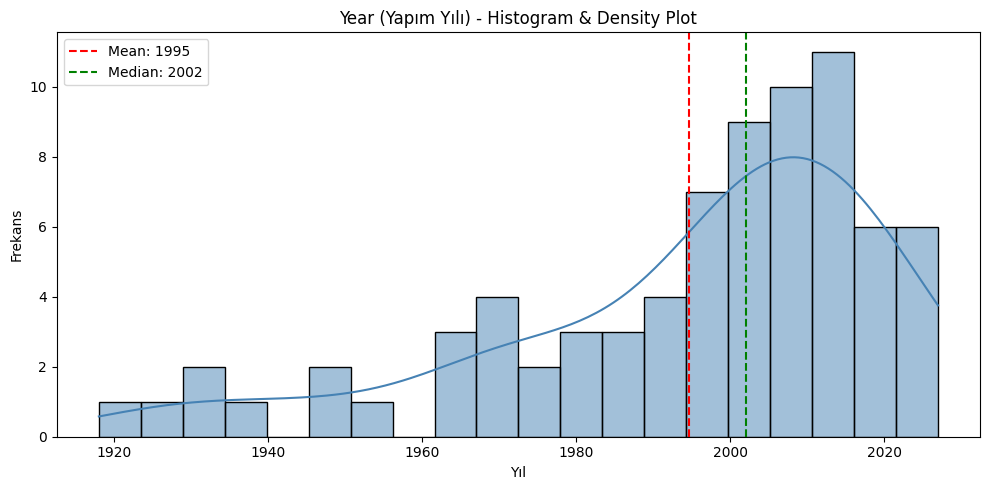

In [ ]:
# 4b) Histogram ve density plot
plt.figure(figsize=(10, 5))
sns.histplot(df['year'].dropna(), kde=True, bins=20, color='steelblue')
plt.axvline(df['year'].mean(), color='red', linestyle='--', label=f"Mean: {df['year'].mean():.0f}")
plt.axvline(df['year'].median(), color='green', linestyle='--', label=f"Median: {df['year'].median():.0f}")
plt.title('Year (Yapım Yılı) - Histogram & Density Plot')
plt.xlabel('Yıl')
plt.ylabel('Frekans')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 5a) Duplicate tespiti
duplicates = df.duplicated()
print(f"Toplam duplicate satır sayısı: {duplicates.sum()}")

if duplicates.sum() > 0:
    print(f"\nDuplicate satırlar:\n{df[duplicates]}")
else:
    print("Veri setinde duplicate kayıt bulunmamaktadır.")

Toplam duplicate satır sayısı: 0
Veri setinde duplicate kayıt bulunmamaktadır.


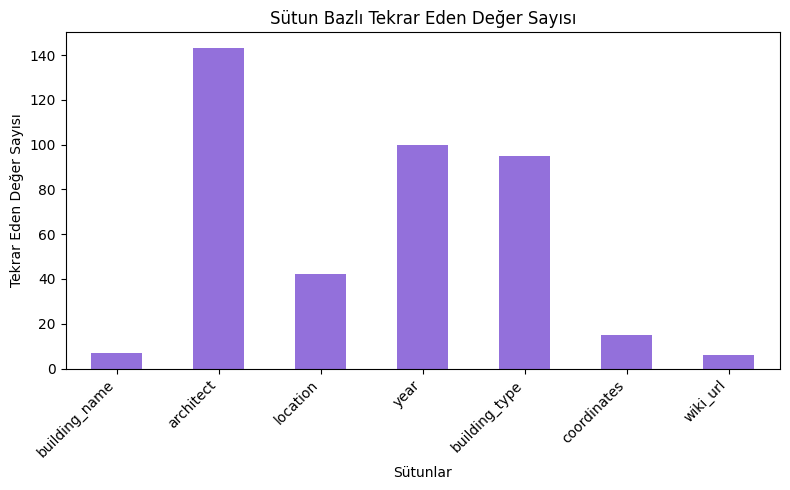

In [ ]:
# 5b) Sütun bazlı tekrar eden değer sayıları
plt.figure(figsize=(8, 5))
repeat_counts = df.apply(lambda x: x.duplicated().sum())
repeat_counts.plot(kind='bar', color='mediumpurple')
plt.title('Sütun Bazlı Tekrar Eden Değer Sayısı')
plt.ylabel('Tekrar Eden Değer Sayısı')
plt.xlabel('Sütunlar')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# 6a) Kategorik değişkenlerin yüzdelik dağılımı
cat_cols = df.select_dtypes(include=object).columns
for col in cat_cols:
    counts = df[col].value_counts()
    percentages = (counts / counts.sum() * 100).round(2)
    print(f"\n{col} dağılımı:")
    print(counts)
    print(f"\n{col} yüzdelik dağılım:")
    print(percentages.apply(lambda x: f"{x:.2f}%"))


building_name dağılımı:
building_name
Wikipedia:FAQ/Categorization            7
Holborn Bars                            2
125 Park Road                           1
Compass Centre                          1
Donald Danforth Plant Science Center    1
                                       ..
Reading School                          1
St Elisabeth's Church, Reddish          1
Rochdale Town Hall                      1
Victoria University of Manchester       1
Whitehall Court                         1
Name: count, Length: 143, dtype: int64

building_name yüzdelik dağılım:
building_name
Wikipedia:FAQ/Categorization            4.67%
Holborn Bars                            1.33%
125 Park Road                           0.67%
Compass Centre                          0.67%
Donald Danforth Plant Science Center    0.67%
                                        ...  
Reading School                          0.67%
St Elisabeth's Church, Reddish          0.67%
Rochdale Town Hall                      0.67%

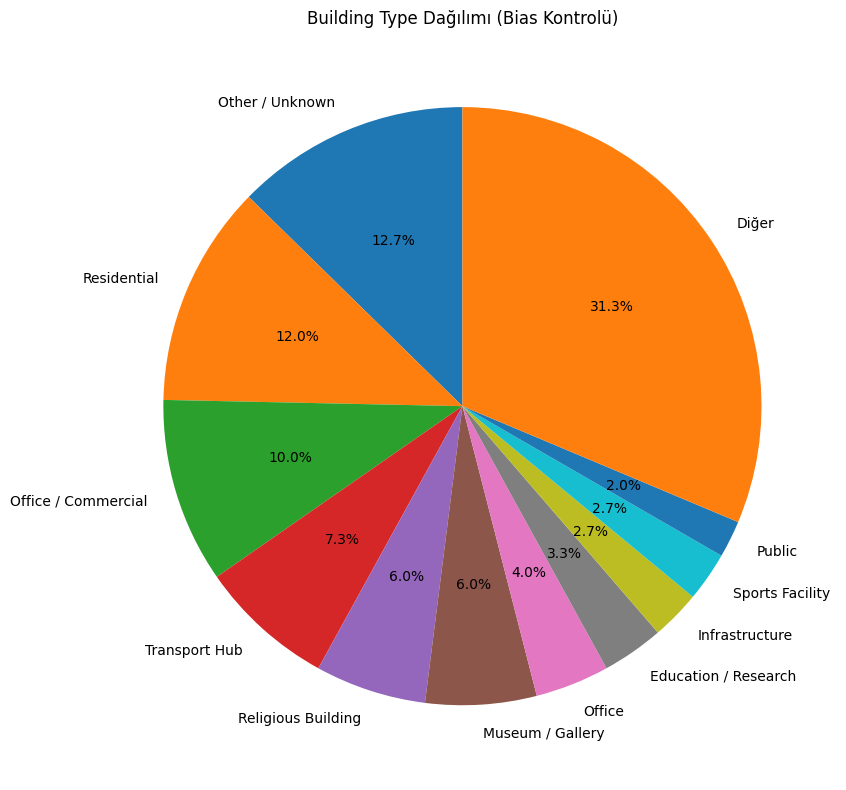

In [ ]:
# 6b) building_type bias görselleştirme (pie chart)
plt.figure(figsize=(10, 8))
type_counts = df['building_type'].value_counts()
# Küçük kategorileri "Diğer" altında topluyoruz (okunabilirlik için)
threshold = 3
main_types = type_counts[type_counts >= threshold]
other_count = type_counts[type_counts < threshold].sum()
if other_count > 0:
    main_types['Diğer'] = other_count

main_types.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Building Type Dağılımı (Bias Kontrolü)')
plt.ylabel('')
plt.tight_layout()
plt.show()

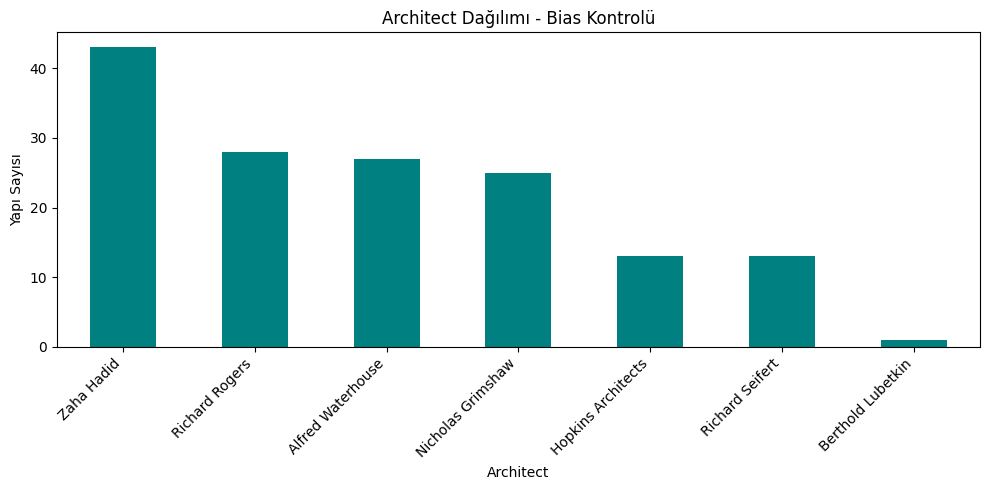

In [ ]:
# 6c) architect bias görselleştirme (bar chart)
plt.figure(figsize=(10, 5))
architect_counts = df['architect'].value_counts()
architect_counts.plot(kind='bar', color='teal')
plt.title('Architect Dağılımı - Bias Kontrolü')
plt.xlabel('Architect')
plt.ylabel('Yapı Sayısı')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances

In [ ]:
# Metin sütunlarını birleştirerek zengin bir metin temsili oluşturuyoruz
df["combined_text"] = (df["building_name"].fillna("") + " " +
                        df["architect"].fillna("") + " " +
                        df["location"].fillna("") + " " +
                        df["building_type"].fillna(""))

vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(df["combined_text"])

dist_matrix = cosine_distances(X)
avg_dist = dist_matrix.mean(axis=1)
threshold = np.percentile(avg_dist, 90)
semantic_outliers = df.iloc[np.where(avg_dist > threshold)[0]]

print(f"Toplam semantic outlier sayısı: {len(semantic_outliers)}")
print(f"Eşik değer (threshold): {threshold:.4f}")
print("\nSemantic outliers:")
semantic_outliers[["building_name", "building_type", "architect"]].head()

Toplam semantic outlier sayısı: 15
Eşik değer (threshold): 0.9773

Semantic outliers:


,building_name,building_type,architect
8,Enneüs Heerma Bridge,Infrastructure,Nicholas Grimshaw
14,Neville Bonner Bridge,Infrastructure,Nicholas Grimshaw
17,Pulkovo Airport,International,Nicholas Grimshaw
24,Zurich Airport,Public,Nicholas Grimshaw
40,Danjiang Bridge,Infrastructure,Zaha Hadid


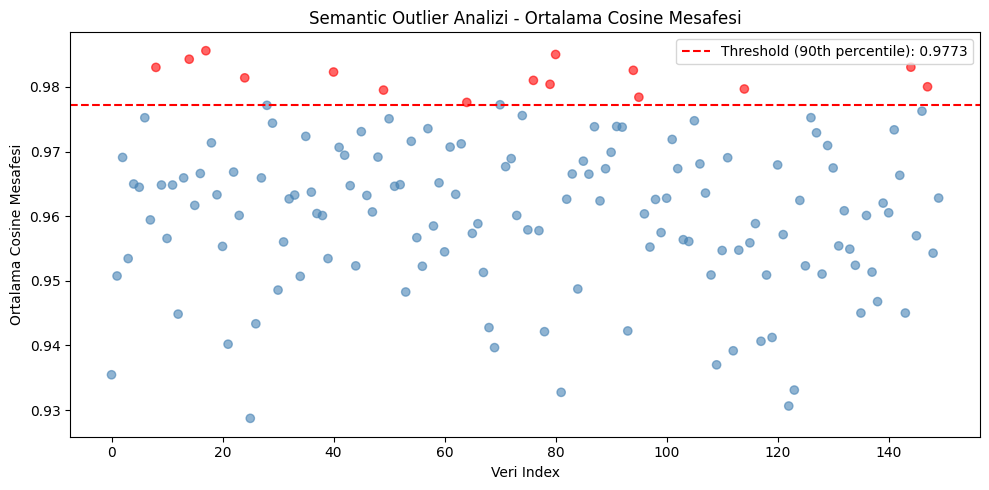

In [ ]:
# Semantic outlier görselleştirmesi
plt.figure(figsize=(10, 5))
colors = ['red' if d > threshold else 'steelblue' for d in avg_dist]
plt.scatter(range(len(avg_dist)), avg_dist, c=colors, alpha=0.6)
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold (90th percentile): {threshold:.4f}')
plt.title('Semantic Outlier Analizi - Ortalama Cosine Mesafesi')
plt.xlabel('Veri Index')
plt.ylabel('Ortalama Cosine Mesafesi')
plt.legend()
plt.tight_layout()
plt.show()

# Geçici sütunu kaldır
df.drop(columns=["combined_text"], inplace=True)

In [ ]:
df_fill = df.copy()
for col in df_fill.columns:
    if df_fill[col].dtype in [np.float64, np.int64]:
        df_fill[col].fillna(df_fill[col].median(), inplace=True)
    elif df_fill[col].dtype == object:
        df_fill[col].fillna("Missing", inplace=True)

print("Doldurma sonrası eksik veri kontrolü:")
print(df_fill.isna().sum())

Doldurma sonrası eksik veri kontrolü:
building_name    0
architect        0
location         0
year             0
building_type    0
coordinates      0
wiki_url         0
dtype: int64


/tmp/ipykernel_19512/1819981256.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fill[col].fillna("Missing", inplace=True)
/tmp/ipykernel_19512/1819981256.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us